<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/machine_learning/lab%20-%20Decision%20Trees%20from%20scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Trees from Scratch: How a Split Is Chosen

**Theory:** [notes_ML/06_decision_trees_cart.ipynb](../notes_ML/06_decision_trees_cart.ipynb), sections 3-6 and 8.

A decision tree asks a series of yes/no questions like *"did the student study at most 4.5 hours?"*. Growing a tree means repeating **one decision** over and over: *which question should this node ask?* This lab looks only at that decision, step by step and with a picture at every step. We do **not** build a full tree class here; the next lab (*Decision Trees and Random Forests*) uses the `scikit-learn` one.

1. What a split is
2. How mixed is a node? Gini and entropy
3. Scoring a split: information gain
4. Trying every threshold
5. Trying every feature
6. Regression: splits that reduce the MSE
7. Recursion: do it again on each side
8. Exercises

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.style.use('seaborn-v0_8-whitegrid')

CLASS_COLORS = np.array(['#E69F00', '#0072B2'])   # 0 = fail (orange), 1 = pass (blue)
CLASS_NAMES = ['fail', 'pass']

The next cell only defines plotting helpers used for the pictures. You can run it without reading it.

In [2]:
# ---------- Plotting helpers (you can skip reading this cell) ----------

def plot_number_line(ax, x, y, xlabel, threshold=None, colors=CLASS_COLORS):
    """Samples as dots on a line, coloured by class. Optional threshold with the two sides marked."""
    lo, hi = x.min() - 1, x.max() + 1
    ax.axhline(0, color='grey', lw=1, zorder=1)
    ax.scatter(x, np.zeros_like(x), c=colors[y], s=220, edgecolors='k', zorder=3)
    if threshold is not None:
        ax.axvspan(lo, threshold, color='grey', alpha=0.10, zorder=0)
        ax.axvline(threshold, color='k', ls='--', lw=1.5)
        ax.text(threshold, 0.75, rf'  $\theta$ = {threshold:g}', ha='left', fontsize=11)
        ax.text((lo + threshold) / 2, -0.7, 'yes: go LEFT', ha='center', fontsize=10)
        ax.text((threshold + hi) / 2, -0.7, 'no: go RIGHT', ha='center', fontsize=10)
    ax.set(xlim=(lo, hi), ylim=(-1, 1), yticks=[], xlabel=xlabel)
    ax.grid(axis='y', visible=False)
    for s in ['left', 'right', 'top']:
        ax.spines[s].set_visible(False)


def _node_box(ax, cx, cy, y, lines, colors=CLASS_COLORS):
    """One tree node: its samples as coloured dots above a text box."""
    y_sorted = np.sort(y)
    xs = cx + (np.arange(len(y_sorted)) - (len(y_sorted) - 1) / 2) * 0.035
    ax.scatter(xs, np.full(len(xs), cy + 0.09), c=colors[y_sorted], s=90, edgecolors='k', zorder=3)
    ax.text(cx, cy - 0.04, '\n'.join(lines), ha='center', va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='grey'))


def counts_text(y):
    return ' · '.join(f'{np.sum(y == k)} {CLASS_NAMES[k]}' for k in range(len(CLASS_NAMES)))


def draw_split_diagram(ax, y, left_mask, question, impurity_fn, name):
    """Parent node, question, two children, and the gain computation underneath."""
    yl, yr = y[left_mask], y[~left_mask]
    n, nl, nr = len(y), len(yl), len(yr)
    ip, il, ir = impurity_fn(y), impurity_fn(yl), impurity_fn(yr)
    weighted = nl / n * il + nr / n * ir

    ax.set(xlim=(0, 1), ylim=(-0.3, 1.1))
    ax.axis('off')
    _node_box(ax, 0.5, 0.9, y, [counts_text(y), f'{name} = {ip:.3f}', f'{question}'])
    for cx, label in [(0.22, 'yes'), (0.78, 'no')]:
        ax.annotate('', xy=(cx, 0.5), xytext=(0.5, 0.6),
                    arrowprops=dict(arrowstyle='->', color='grey', lw=1.5))
        ax.text((cx + 0.5) / 2, 0.57, label, ha='center', fontsize=10, fontweight='bold')
    _node_box(ax, 0.22, 0.34, yl, [counts_text(yl), f'{name} = {il:.3f}', f'weight = {nl}/{n}'])
    _node_box(ax, 0.78, 0.34, yr, [counts_text(yr), f'{name} = {ir:.3f}', f'weight = {nr}/{n}'])
    ax.text(0.5, -0.2,
            f'weighted children = {nl}/{n}·{il:.3f} + {nr}/{n}·{ir:.3f} = {weighted:.3f}\n'
            f'gain = {ip:.3f} − {weighted:.3f} = {ip - weighted:.3f}',
            ha='center', va='center', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.4', fc='#f3f3f3', ec='none'))


def plot_gain_scan(ax, thresholds, gains, xlabel, ylabel, color='steelblue'):
    """Bar per candidate threshold, best one highlighted."""
    best = int(np.argmax(gains))
    bar_colors = [color] * len(gains)
    bar_colors[best] = 'crimson'
    width = 0.6 * np.min(np.diff(thresholds)) if len(thresholds) > 1 else 0.5
    ax.bar(thresholds, gains, width=width, color=bar_colors)
    ax.set(xlabel=xlabel, ylabel=ylabel)
    ax.annotate(rf'best $\theta$ = {thresholds[best]:g}', xy=(thresholds[best], gains[best]),
                xytext=(0, 8), textcoords='offset points', ha='center', color='crimson')
    ax.set_ylim(0, max(gains) * 1.25 if max(gains) > 0 else 1)

## 1. What Is a Split?

Our running example: 10 students, two features (hours studied, hours slept the night before) and a label (passed the exam or not).

In [3]:
studied = np.array([1, 2, 3, 3.5, 4, 5, 6, 7, 8, 9])
slept   = np.array([7, 6, 9, 5,   8, 6, 7, 4, 8, 5])
passed  = np.array([0, 0, 1, 0,   0, 1, 1, 0, 1, 1])   # 1 = pass, 0 = fail

X = np.column_stack([studied, slept])
y = passed
feature_names = ['studied', 'slept']

pd.DataFrame({'hours studied': studied, 'hours slept': slept,
              'result': [CLASS_NAMES[k] for k in passed]})

,hours studied,hours slept,result
0,1.0,7,fail
1,2.0,6,fail
2,3.0,9,pass
3,3.5,5,fail
4,4.0,8,fail
5,5.0,6,pass
6,6.0,7,pass
7,7.0,4,fail
8,8.0,8,pass
9,9.0,5,pass


Let's look at one feature, `studied`, on a line. Each dot is a student: **blue = pass, orange = fail**.

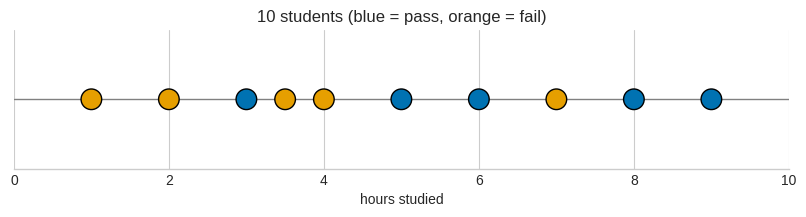

In [4]:
fig, ax = plt.subplots(figsize=(10, 1.8))
plot_number_line(ax, studied, passed, 'hours studied')
ax.set_title('10 students (blue = pass, orange = fail)')
plt.show()

A **split** is one question of the form

$$\text{is } x_j \le \theta \text{ ?}$$

with one feature $x_j$ and one **threshold** $\theta$. The students who answer *yes* go to the **left child**, the others to the **right child**. Here is the question *"studied ≤ 4.5?"*. On the right is the same split drawn as a tiny tree:

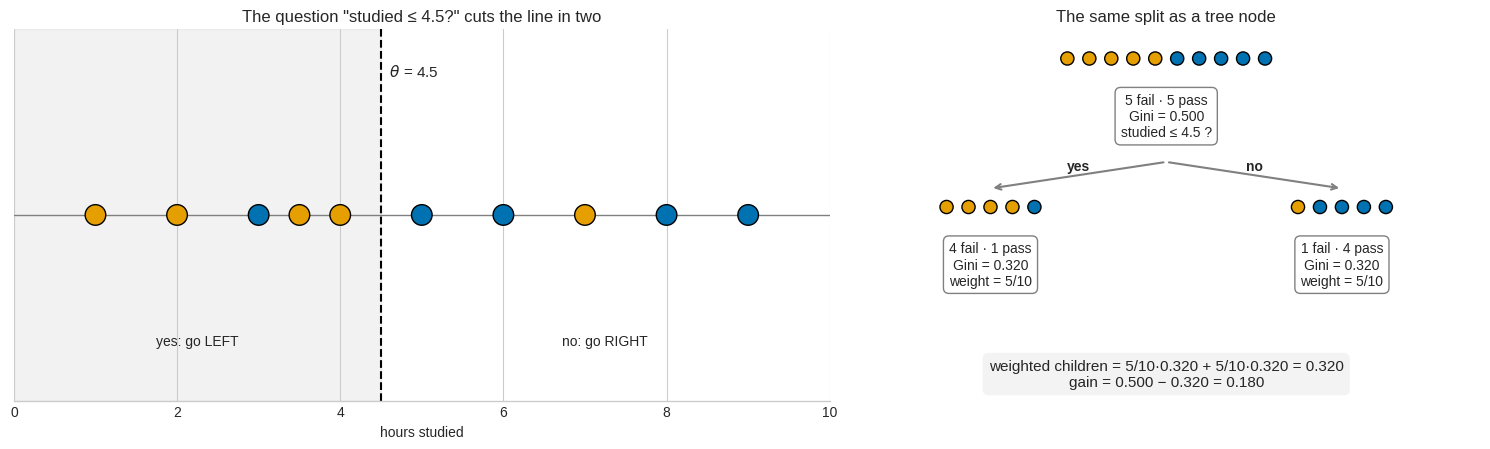

In [5]:
def gini(y):   # a first definition, explained properly in section 2
    _, counts = np.unique(y, return_counts=True)
    return 1 - np.sum((counts / len(y)) ** 2)

fig, ax = plt.subplots(1, 2, figsize=(15, 4.6), gridspec_kw={'width_ratios': [1.3, 1]})
plot_number_line(ax[0], studied, passed, 'hours studied', threshold=4.5)
ax[0].set_title('The question "studied ≤ 4.5?" cuts the line in two')
draw_split_diagram(ax[1], passed, studied <= 4.5, 'studied ≤ 4.5 ?', gini, 'Gini')
ax[1].set_title('The same split as a tree node')
plt.tight_layout()
plt.show()

The left child is mostly *fail* (4 of 5) and the right child is mostly *pass* (4 of 5). If we stopped here, the tree would predict "fail" on the left and "pass" on the right, and be right 8 times out of 10.

Compare with a poor question, *"studied ≤ 1.5?"*:

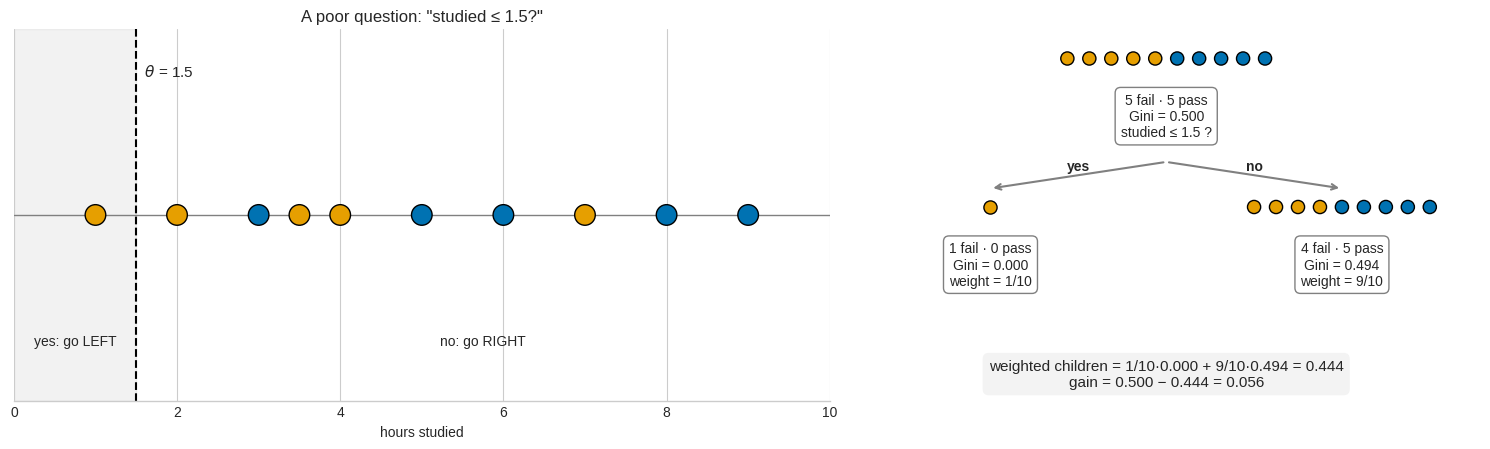

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.6), gridspec_kw={'width_ratios': [1.3, 1]})
plot_number_line(ax[0], studied, passed, 'hours studied', threshold=1.5)
ax[0].set_title('A poor question: "studied ≤ 1.5?"')
draw_split_diagram(ax[1], passed, studied <= 1.5, 'studied ≤ 1.5 ?', gini, 'Gini')
plt.tight_layout()
plt.show()

It only peels off one student. The right child (4 fail, 5 pass) is almost as mixed as before, so we have learned very little.

To let a computer tell good questions from bad ones we need **numbers**:

1. a number that says how **mixed** a node is (its *impurity*, section 2), and
2. a number that says how much a split **reduces** that mixing (its *gain*, section 3).

The boxes above already show both; the next two sections explain where they come from.

## 2. How Mixed Is a Node? Impurity

A node is **pure** when all its samples have the same class: a leaf there can predict with no doubt. A node is **maximally mixed** when all classes are equally common. We want a number that is:

- $0$ for a pure node,
- largest for a 50/50 (or uniform) node,
- in between otherwise.

Everything below uses $p_k$ = **fraction of the node's samples in class $k$**. For a node with 4 fail and 1 pass: $p_\text{fail} = 4/5 = 0.8$, $p_\text{pass} = 1/5 = 0.2$.

### 2.1 Gini impurity

$$I_\text{Gini} = 1 - \sum_k p_k^2$$

**Intuition.** Pick two students from the node at random (with replacement). $\sum_k p_k^2$ is the probability that both have the *same* class, so Gini is the probability that they have **different** classes. In a pure node they always agree (Gini $=0$).

**By hand**, node with 4 fail and 1 pass:

$$I_\text{Gini} = 1 - (0.8^2 + 0.2^2) = 1 - (0.64 + 0.04) = 0.32$$

In code: 1) count each class, 2) turn counts into fractions $p_k$, 3) apply the formula.

In [7]:
def gini(y):
    # Gini impurity of a label array
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)   # 1) count each class
    p = counts / len(y)                            # 2) fractions p_k
    return 1.0 - np.sum(p ** 2)                    # 3) formula


print(f"5 fail, 0 pass : Gini = {gini(np.array([0, 0, 0, 0, 0])):.3f}")
print(f"4 fail, 1 pass : Gini = {gini(np.array([0, 0, 0, 0, 1])):.3f}")
print(f"3 fail, 2 pass : Gini = {gini(np.array([0, 0, 0, 1, 1])):.3f}")
print(f"5 fail, 5 pass : Gini = {gini(np.array([0] * 5 + [1] * 5)):.3f}")

5 fail, 0 pass : Gini = 0.000
4 fail, 1 pass : Gini = 0.320
3 fail, 2 pass : Gini = 0.480
5 fail, 5 pass : Gini = 0.500


### 2.2 Entropy

$$I_\text{entropy} = -\sum_k p_k \log_2 p_k \qquad (\text{with } 0 \log_2 0 = 0)$$

**Intuition.** Entropy is the average number of yes/no questions (bits) you need to guess the class of a random sample from the node. Pure node: you already know the answer, $0$ bits. 50/50 node: one coin flip, $1$ bit.

**By hand**, the same 4 fail / 1 pass node ($\log_2 0.8 = -0.322$, $\log_2 0.2 = -2.322$):

$$I_\text{entropy} = -(0.8 \cdot (-0.322) + 0.2 \cdot (-2.322)) = 0.258 + 0.464 = 0.722 \text{ bits}$$

In code it is the same three steps; only step 3 changes. `np.unique` never returns a class with count 0, so we never compute $\log_2 0$.

In [8]:
def entropy(y):
    # Shannon entropy (base 2) of a label array
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    p = counts / len(y)
    return max(0.0, -np.sum(p * np.log2(p)))   # max(0, ...) avoids printing -0.0


for labels in [[0, 0, 0, 0, 0], [0, 0, 0, 0, 1], [0, 0, 0, 1, 1], [0] * 5 + [1] * 5]:
    labels = np.array(labels)
    print(f"{counts_text(labels):>15} : Gini = {gini(labels):.3f}   entropy = {entropy(labels):.3f}")

5 fail · 0 pass : Gini = 0.000   entropy = 0.000
4 fail · 1 pass : Gini = 0.320   entropy = 0.722
3 fail · 2 pass : Gini = 0.480   entropy = 0.971
5 fail · 5 pass : Gini = 0.500   entropy = 1.000


### 2.3 Seeing both at once

Each box below is a node; the dots are its samples. The more mixed the colours, the higher both numbers.

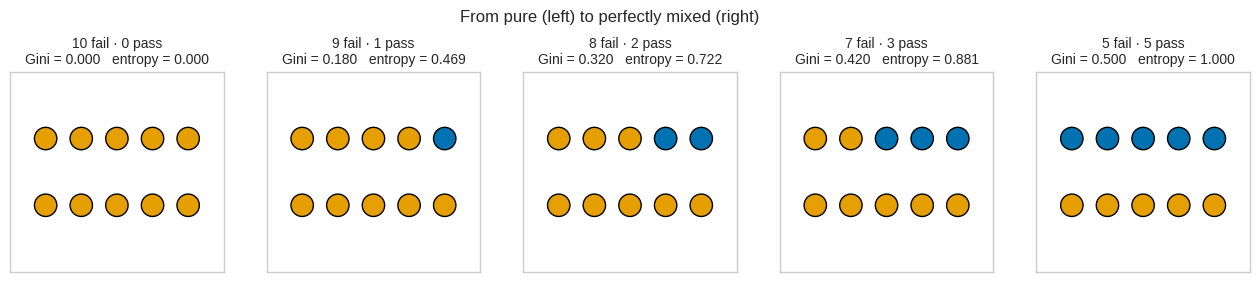

In [9]:
example_nodes = [np.array([0] * 10), np.array([0] * 9 + [1]), np.array([0] * 8 + [1] * 2),
                 np.array([0] * 7 + [1] * 3), np.array([0] * 5 + [1] * 5)]

fig, axes = plt.subplots(1, len(example_nodes), figsize=(16, 2.6))
for ax, node in zip(axes, example_nodes):
    rows = np.sort(node).reshape(2, 5)
    for r in range(2):
        ax.scatter(np.arange(5), np.full(5, r), c=CLASS_COLORS[rows[r]], s=260, edgecolors='k')
    ax.set(xlim=(-1, 5), ylim=(-1, 2), xticks=[], yticks=[])
    ax.set_title(f"{counts_text(node)}\nGini = {gini(node):.3f}   entropy = {entropy(node):.3f}", fontsize=10)
plt.suptitle('From pure (left) to perfectly mixed (right)', y=1.12)
plt.show()

For two classes both measures depend only on $p$ = fraction of *pass*. Plotting them over all $p$ (the dots are the five nodes above):

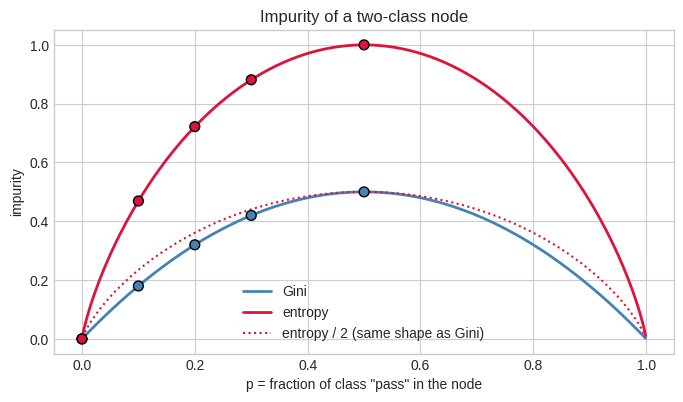

In [10]:
p = np.linspace(0.001, 0.999, 400)
gini_curve = 1 - (p ** 2 + (1 - p) ** 2)
entropy_curve = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(p, gini_curve, color='steelblue', lw=2, label='Gini')
ax.plot(p, entropy_curve, color='crimson', lw=2, label='entropy')
ax.plot(p, entropy_curve / 2, color='crimson', lw=1.5, ls=':', label='entropy / 2 (same shape as Gini)')
for node in example_nodes:
    pn = node.mean()
    ax.scatter([pn, pn], [gini(node), entropy(node)], color=['steelblue', 'crimson'], s=50, zorder=3, edgecolors='k')
ax.set(xlabel='p = fraction of class "pass" in the node', ylabel='impurity',
       title='Impurity of a two-class node')
ax.legend()
plt.show()

- Both are $0$ at $p=0$ and $p=1$ (pure) and peak at $p=0.5$: Gini at $0.5$, entropy at $1$ bit.
- Halved, entropy almost overlaps Gini. They **rank nodes in nearly the same order**, so in practice they almost always pick the same split.
- `scikit-learn` uses Gini by default (`criterion='gini'`) because it needs no logarithm, so it is a little faster.
- With $K$ classes the maximum grows: Gini $1 - 1/K$, entropy $\log_2 K$ (e.g. $0.667$ and $1.585$ for 3 classes).

## 3. Scoring a Split: Information Gain

A split replaces one **parent** node $S$ by two **children** $S_L$ (yes) and $S_R$ (no). The split is good if the children are, on average, much purer than the parent:

$$\text{Gain} = \underbrace{I(S)}_{\text{parent}} - \underbrace{\left(\frac{N_L}{N}\, I(S_L) + \frac{N_R}{N}\, I(S_R)\right)}_{\text{weighted average of the children}}$$

$N$, $N_L$, $N_R$ are the number of samples in the parent and in each child. With entropy this is called the **information gain**; with Gini, the *Gini decrease*. Both are cases of the **impurity decrease**.

**By hand**, split *"studied ≤ 4.5?"* (parent: 5 fail, 5 pass):

| | samples | Gini | entropy |
|---|---|---|---|
| Parent | 5 fail · 5 pass | $0.5$ | $1$ |
| Left child (yes) | 4 fail · 1 pass (weight $5/10$) | $0.32$ | $0.722$ |
| Right child (no) | 1 fail · 4 pass (weight $5/10$) | $0.32$ | $0.722$ |
| Weighted children | $\frac{5}{10} I_L + \frac{5}{10} I_R$ | $0.32$ | $0.722$ |
| **Gain** | parent − weighted | $\mathbf{0.18}$ | $\mathbf{0.278}$ |

In code: 1) split the labels with a mask, 2) impurity of the parent and of each child, 3) weighted average, 4) subtract.

In [11]:
def split_gain(x, y, threshold, impurity_fn):
    # Impurity decrease of the split "x <= threshold"
    left = x <= threshold                                      # 1) yes / no mask
    n, n_left, n_right = len(y), left.sum(), (~left).sum()
    weighted = (n_left / n * impurity_fn(y[left]) +            # 2) + 3)
                n_right / n * impurity_fn(y[~left]))
    return impurity_fn(y) - weighted                           # 4)


for t in [4.5, 1.5]:
    print(f"studied <= {t}:  Gini gain = {split_gain(studied, passed, t, gini):.3f}   "
          f"information gain = {split_gain(studied, passed, t, entropy):.3f}")

studied <= 4.5:  Gini gain = 0.180   information gain = 0.278
studied <= 1.5:  Gini gain = 0.056   information gain = 0.108


The good split gains $0.18$ (Gini), the poor one only $0.056$. With entropy the numbers are different ($0.278$ vs $0.108$) but the **order is the same**. Both splits drawn with entropy:

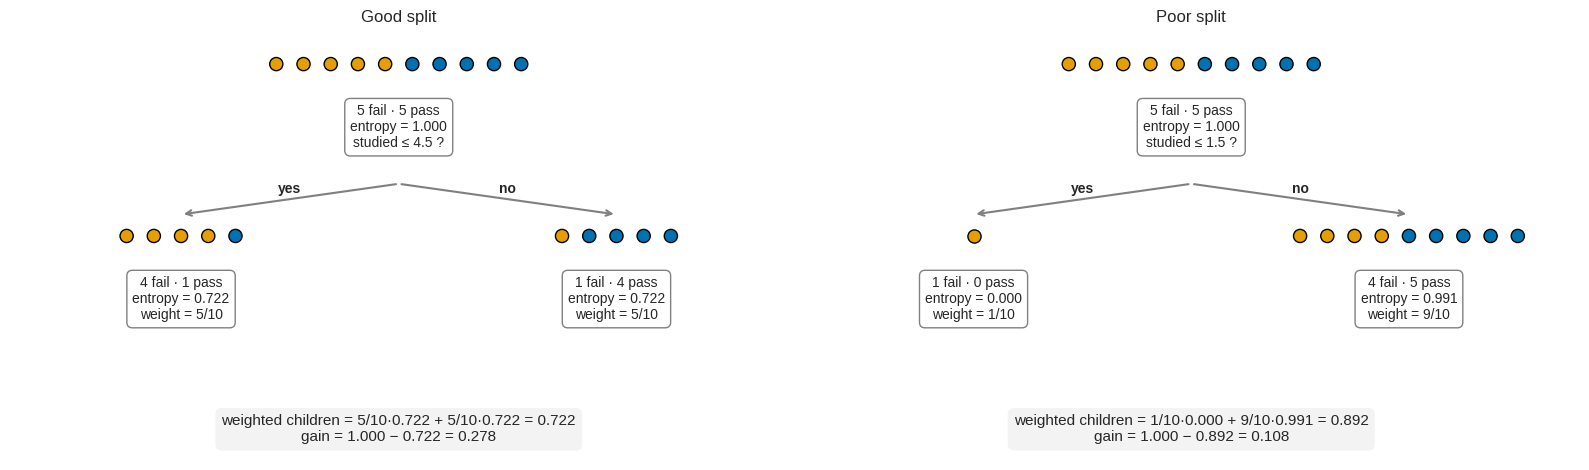

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4.8))
draw_split_diagram(ax[0], passed, studied <= 4.5, 'studied ≤ 4.5 ?', entropy, 'entropy')
draw_split_diagram(ax[1], passed, studied <= 1.5, 'studied ≤ 1.5 ?', entropy, 'entropy')
ax[0].set_title('Good split', fontsize=12)
ax[1].set_title('Poor split', fontsize=12)
plt.tight_layout()
plt.show()

### Why weight the children by their size?

In the poor split the left child is **perfectly pure**, but it holds a single student. A plain average of the two children would reward that:

$$\text{plain average} = \tfrac{1}{2}(0 + 0.494) = 0.247 \quad\Rightarrow\quad \text{"gain"} = 0.5 - 0.247 = 0.253 > 0.18$$

and the tree would prefer peeling off one student over the sensible split. Weighting by size counts every **student** equally, not every node: the pure child only gets weight $1/10$, and the gain falls to $0.056$.

In [13]:
left = studied <= 1.5
plain = (gini(passed[left]) + gini(passed[~left])) / 2
print(f"Plain average of children : {plain:.3f}  ->  'gain' {gini(passed) - plain:.3f}  (wrongly beats 0.180)")
print(f"Weighted average          : {gini(passed) - split_gain(studied, passed, 1.5, gini):.3f}  ->  gain {split_gain(studied, passed, 1.5, gini):.3f}")

Plain average of children : 0.247  ->  'gain' 0.253  (wrongly beats 0.180)
Weighted average          : 0.444  ->  gain 0.056


## 4. Trying Every Threshold

Which $\theta$ should we try? There are infinitely many real numbers, but only a few **different splits**: moving $\theta$ inside a gap between two neighbouring students sends exactly the same students left. So:

- sort the distinct values of the feature,
- take one candidate per gap, **the midpoint** between neighbours (`scikit-learn` does the same),
- with $n$ distinct values that gives only $n - 1$ candidates.

The dashed lines are the 9 candidates for `studied`:

sorted values: [1.  2.  3.  3.5 4.  5.  6.  7.  8.  9. ]
candidates   : [1.5  2.5  3.25 3.75 4.5  5.5  6.5  7.5  8.5 ]


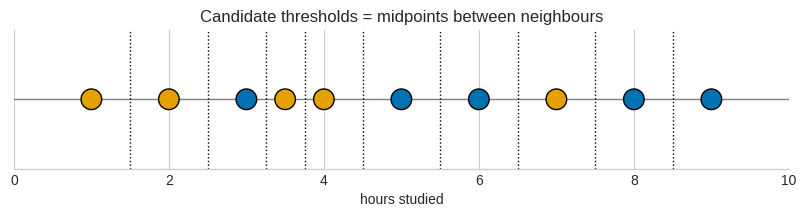

In [14]:
values = np.unique(studied)
candidates = (values[:-1] + values[1:]) / 2
print("sorted values:", values)
print("candidates   :", candidates)

fig, ax = plt.subplots(figsize=(10, 1.8))
plot_number_line(ax, studied, passed, 'hours studied')
for t in candidates:
    ax.axvline(t, color='k', ls=':', lw=1)
ax.set_title('Candidate thresholds = midpoints between neighbours')
plt.show()

Now compute the gain of every candidate and keep the largest.

In code: 1) sorted distinct values, 2) midpoints, 3) `split_gain` for each, 4) `argmax`.

In [15]:
def threshold_gains(x, y, impurity_fn):
    # Gain of every candidate threshold on one feature
    values = np.unique(x)                              # 1) sorted, distinct
    thresholds = (values[:-1] + values[1:]) / 2        # 2) midpoints
    gains = np.array([split_gain(x, y, t, impurity_fn) for t in thresholds])   # 3)
    return thresholds, gains


def best_threshold(x, y, impurity_fn):
    thresholds, gains = threshold_gains(x, y, impurity_fn)
    if len(thresholds) == 0:                           # constant feature: nothing to split
        return None, 0.0
    best = np.argmax(gains)                            # 4)
    return thresholds[best], gains[best]


for fn in [gini, entropy]:
    thresholds, gains = threshold_gains(studied, passed, fn)
    print(f"{fn.__name__:>8}:", '  '.join(f"{t:g}->{g:.3f}" for t, g in zip(thresholds, gains)))

    gini: 1.5->0.056  2.5->0.125  3.25->0.024  3.75->0.083  4.5->0.180  5.5->0.083  6.5->0.024  7.5->0.125  8.5->0.056
 entropy: 1.5->0.108  2.5->0.236  3.25->0.035  3.75->0.125  4.5->0.278  5.5->0.125  6.5->0.035  7.5->0.236  8.5->0.108


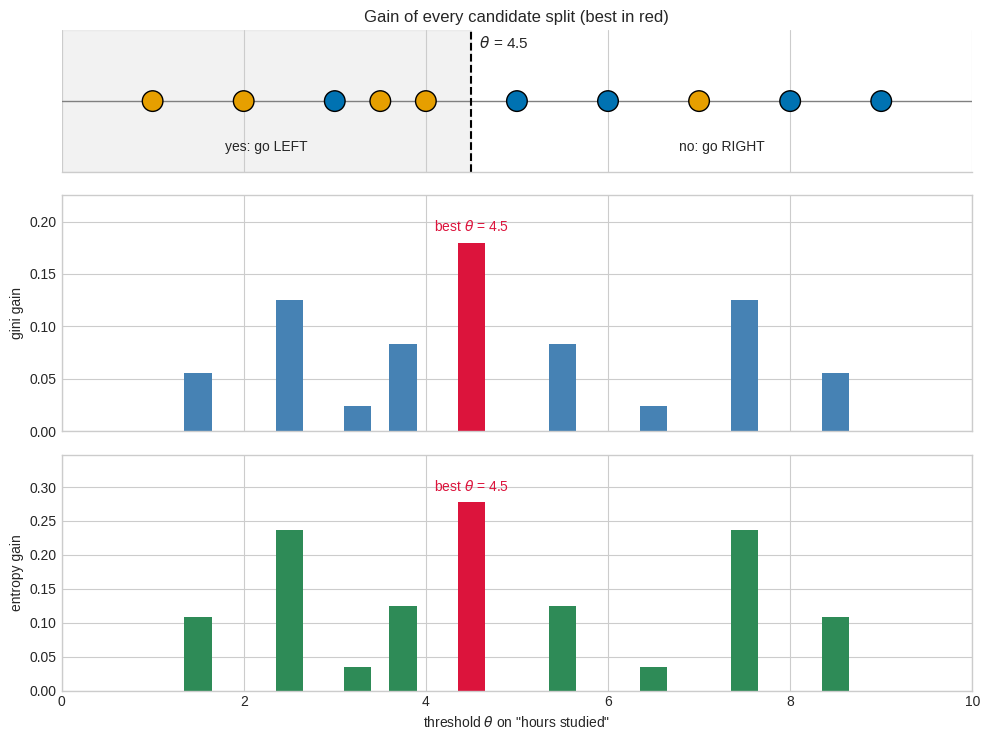

In [16]:
fig, ax = plt.subplots(3, 1, figsize=(10, 7.5), sharex=True, gridspec_kw={'height_ratios': [0.6, 1, 1]})
plot_number_line(ax[0], studied, passed, '', threshold=4.5)
for a, fn, color in [(ax[1], gini, 'steelblue'), (ax[2], entropy, 'seagreen')]:
    thresholds, gains = threshold_gains(studied, passed, fn)
    plot_gain_scan(a, thresholds, gains, '', f'{fn.__name__} gain', color=color)
ax[2].set_xlabel(r'threshold $\theta$ on "hours studied"')
ax[0].set_title('Gain of every candidate split (best in red)')
plt.tight_layout()
plt.show()

- Both criteria pick $\theta = 4.5$.
- The gain is **not a smooth function** of $\theta$: it jumps up and down as single students switch sides. We cannot use gradient descent here, but we don't need to: there are only $n-1$ candidates, so we simply try them all.
- The poor split $\theta = 1.5$ is at the far left, one of the lowest bars.

**Try it yourself** (optional, needs `ipywidgets`, which Colab has): move the slider and watch the children and the gain change.

In [17]:
try:
    from ipywidgets import interact, FloatSlider

    def show_split(threshold=4.5, criterion='gini'):
        fn = gini if criterion == 'gini' else entropy
        fig, ax = plt.subplots(1, 2, figsize=(15, 4.6), gridspec_kw={'width_ratios': [1.3, 1]})
        plot_number_line(ax[0], studied, passed, 'hours studied', threshold=threshold)
        draw_split_diagram(ax[1], passed, studied <= threshold, f'studied ≤ {threshold:g} ?', fn, criterion)
        plt.tight_layout()
        plt.show()

    interact(show_split, threshold=FloatSlider(value=4.5, min=0.5, max=9.5, step=0.25),
             criterion=['gini', 'entropy'])
except ImportError:
    print("ipywidgets is not installed; skip this cell.")

interactive(children=(FloatSlider(value=4.5, description='threshold', max=9.5, min=0.5, step=0.25), Dropdown(d…

## 5. Trying Every Feature

With several features we run the threshold search **on each feature** and keep the best (feature, threshold) pair overall. That is the complete split search of CART (notes 06, section 4):

$$(j^*, \theta^*) = \arg\max_{j,\ \theta}\ \text{Gain}(j, \theta)$$

Our students in 2D:

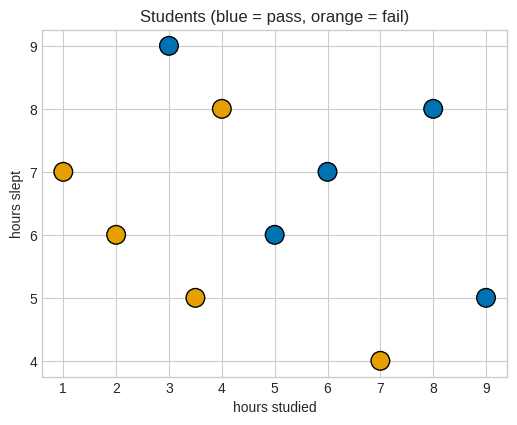

In [18]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(studied, slept, c=CLASS_COLORS[passed], s=180, edgecolors='k')
ax.set(xlabel='hours studied', ylabel='hours slept', title='Students (blue = pass, orange = fail)')
plt.show()

In code: 1) loop over the columns of `X`, 2) find the best threshold of each, 3) keep the feature with the largest gain.

In [19]:
def best_split(X, y, impurity_fn):
    # Best (feature, threshold) pair over all features. feature is None if no split helps.
    best_feature, best_thr, best_gain = None, None, 0.0
    for j in range(X.shape[1]):                                   # 1)
        thr, gain = best_threshold(X[:, j], y, impurity_fn)       # 2)
        if thr is not None and gain > best_gain:                  # 3)
            best_feature, best_thr, best_gain = j, thr, gain
    return best_feature, best_thr, best_gain


for j, name in enumerate(feature_names):
    thr, gain = best_threshold(X[:, j], y, gini)
    print(f"best on {name:<8}: {name} <= {thr:g}   Gini gain = {gain:.3f}")

j, thr, gain = best_split(X, y, gini)
print(f"\nWINNER: {feature_names[j]} <= {thr:g}  (gain {gain:.3f})")

best on studied : studied <= 4.5   Gini gain = 0.180
best on slept   : slept <= 4.5   Gini gain = 0.056

WINNER: studied <= 4.5  (gain 0.180)


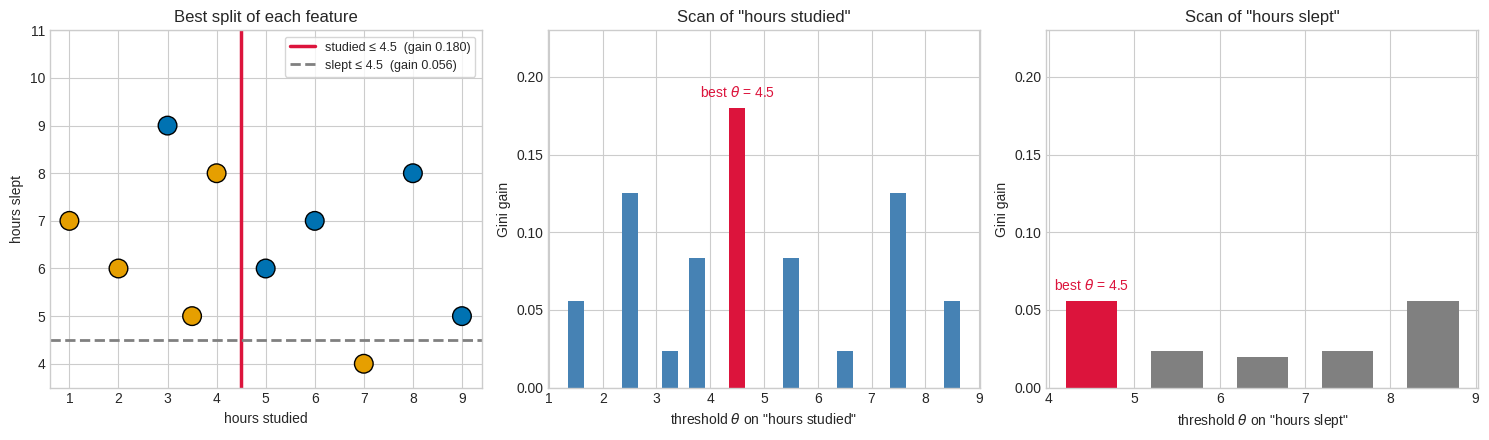

In [20]:
fig = plt.figure(figsize=(15, 4.5))
ax_s = fig.add_subplot(1, 3, 1)
ax_s.scatter(studied, slept, c=CLASS_COLORS[passed], s=180, edgecolors='k', zorder=3)
thr_st, g_st = best_threshold(studied, passed, gini)
thr_sl, g_sl = best_threshold(slept, passed, gini)
ax_s.axvline(thr_st, color='crimson', lw=2.5, label=f'studied ≤ {thr_st:g}  (gain {g_st:.3f})')
ax_s.axhline(thr_sl, color='grey', lw=2, ls='--', label=f'slept ≤ {thr_sl:g}  (gain {g_sl:.3f})')
ax_s.set(xlabel='hours studied', ylabel='hours slept', title='Best split of each feature')
ax_s.set_ylim(3.5, 11)
ax_s.legend(loc='upper right', fontsize=9, frameon=True)

for k, (xj, name, color) in enumerate([(studied, 'hours studied', 'steelblue'), (slept, 'hours slept', 'grey')]):
    a = fig.add_subplot(1, 3, k + 2)
    thresholds, gains = threshold_gains(xj, passed, gini)
    plot_gain_scan(a, thresholds, gains, rf'threshold $\theta$ on "{name}"', 'Gini gain', color=color)
    a.set_ylim(0, 0.23)
    a.set_title(f'Scan of "{name}"')
plt.tight_layout()
plt.show()

`studied` wins clearly ($0.18$ against $0.056$; on `slept`, $4.5$ and $8.5$ tie, each peeling off a single student). Seen alone, sleep looks almost useless. Keep that in mind for section 7.

**Check against scikit-learn.** A tree with `max_depth=1` makes exactly one split, the one CART picks at the root:

In [21]:
from sklearn.tree import DecisionTreeClassifier

stump = DecisionTreeClassifier(max_depth=1, criterion='gini').fit(X, y)
print(f"scikit-learn root split: {feature_names[stump.tree_.feature[0]]} <= {stump.tree_.threshold[0]:g}")
print(f"our root split         : {feature_names[j]} <= {thr:g}")

scikit-learn root split: studied <= 4.5
our root split         : studied <= 4.5


## 6. Regression: Splits That Reduce the MSE

When the target is a **number** (a price, a temperature), there are no classes to count. The same recipe still works; only two things change:

| | Classification | Regression |
|---|---|---|
| A leaf predicts | the majority class | the **mean** $\bar y$ of its samples |
| Impurity of a node | Gini or entropy | **MSE** around that mean |

$$I_\text{MSE}(S) = \frac{1}{N}\sum_{i \in S} (y_i - \bar y_S)^2$$

This is just the **variance** of the node's targets: the average squared error made by predicting $\bar y_S$ for everyone in the node. A "pure" regression node has all targets close to its mean.

The gain is the **MSE decrease**, with the same formula as before:

$$\Delta\text{MSE} = I_\text{MSE}(S) - \left(\frac{N_L}{N} I_\text{MSE}(S_L) + \frac{N_R}{N} I_\text{MSE}(S_R)\right)$$

Example: 10 flats, size in m² and price in k€.

In [22]:
size  = np.array([40, 50, 55, 60, 70, 80, 90, 95, 110, 120])
price = np.array([110, 125, 120, 140, 150, 210, 230, 220, 250, 260])

def mse_impurity(y):
    # Mean squared error around the node mean (= variance)
    if len(y) == 0:
        return 0.0
    return np.mean((y - np.mean(y)) ** 2)

print(f"mean price = {price.mean():.1f} k€   MSE of the root = {mse_impurity(price):.2f}")

mean price = 181.5 k€   MSE of the root = 3030.25


The picture of MSE: each vertical red segment is one error $y_i - \bar y$, and the MSE is the average of their **squares**. A good split makes the segments short on **both** sides:

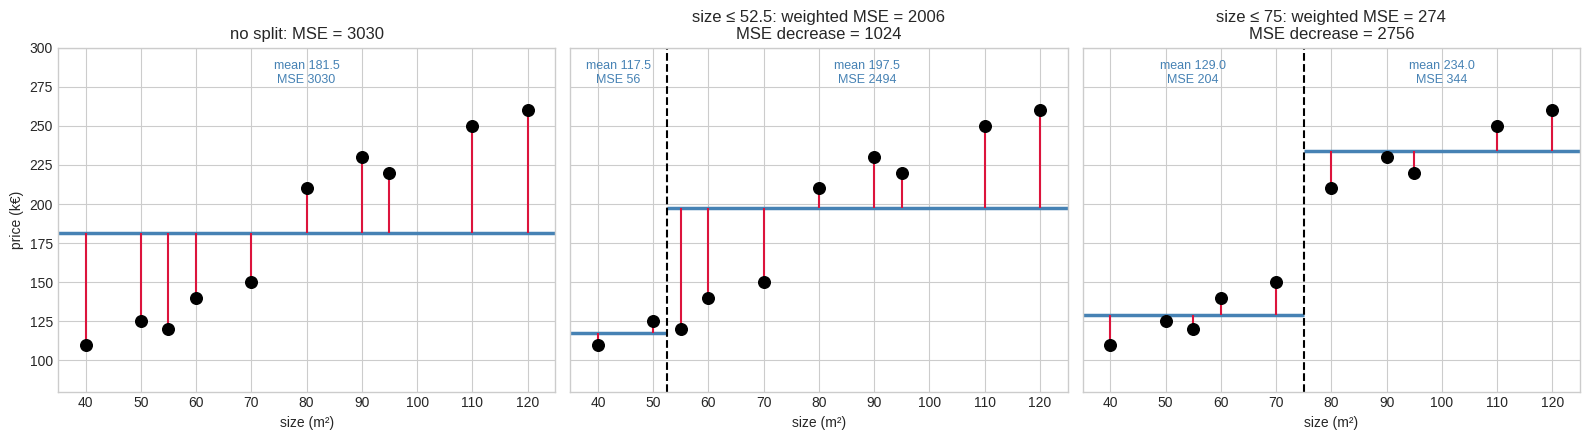

In [23]:
def plot_regression_split(ax, x, y, threshold=None, ylim=(80, 300)):
    ax.scatter(x, y, s=70, color='k', zorder=3)
    groups = [np.ones(len(x), bool)] if threshold is None else [x <= threshold, x > threshold]
    lo, hi = x.min() - 5, x.max() + 5
    edges = [lo, hi] if threshold is None else [lo, threshold, hi]
    weighted = 0.0
    for g, (a, b) in zip(groups, zip(edges[:-1], edges[1:])):
        m = y[g].mean()
        ax.hlines(m, a, b, color='steelblue', lw=2.5)
        ax.vlines(x[g], m, y[g], color='crimson', lw=1.5)
        ax.text((a + b) / 2, ylim[1] - 8, f'mean {m:.1f}\nMSE {mse_impurity(y[g]):.0f}', ha='center',
                va='top', fontsize=9, color='steelblue')
        weighted += g.mean() * mse_impurity(y[g])
    if threshold is not None:
        ax.axvline(threshold, color='k', ls='--')
    title = (f'no split: MSE = {mse_impurity(y):.0f}' if threshold is None else
             f'size ≤ {threshold:g}: weighted MSE = {weighted:.0f}\n'
             f'MSE decrease = {mse_impurity(y) - weighted:.0f}')
    ax.set(xlabel='size (m²)', title=title, xlim=(lo, hi), ylim=ylim)


fig, ax = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
plot_regression_split(ax[0], size, price)
plot_regression_split(ax[1], size, price, threshold=52.5)
plot_regression_split(ax[2], size, price, threshold=75)
ax[0].set_ylabel('price (k€)')
plt.tight_layout()
plt.show()

**By hand**, split *"size ≤ 75?"*:

| | flats | mean price | MSE |
|---|---|---|---|
| Parent | all 10 | $181.5$ | $3030.25$ |
| Left child | 5 (40-70 m²) | $129$ | $204$ |
| Right child | 5 (80-120 m²) | $234$ | $344$ |
| Weighted children | $\frac{5}{10}\cdot 204 + \frac{5}{10}\cdot 344$ | | $274$ |
| **MSE decrease** | $3030.25 - 274$ | | $\mathbf{2756.25}$ |

The split at $52.5$ leaves the right child very spread out (MSE $2493.75$ over 8 flats), so it only reduces the MSE by $1024$.

Our threshold scan from section 4 works **without any change**: we just pass `mse_impurity` instead of `gini`.

45->568  52.5->1024  57.5->1710  65->2223  75->2756  85->2282  92.5->1639  102.5->1351  115->685


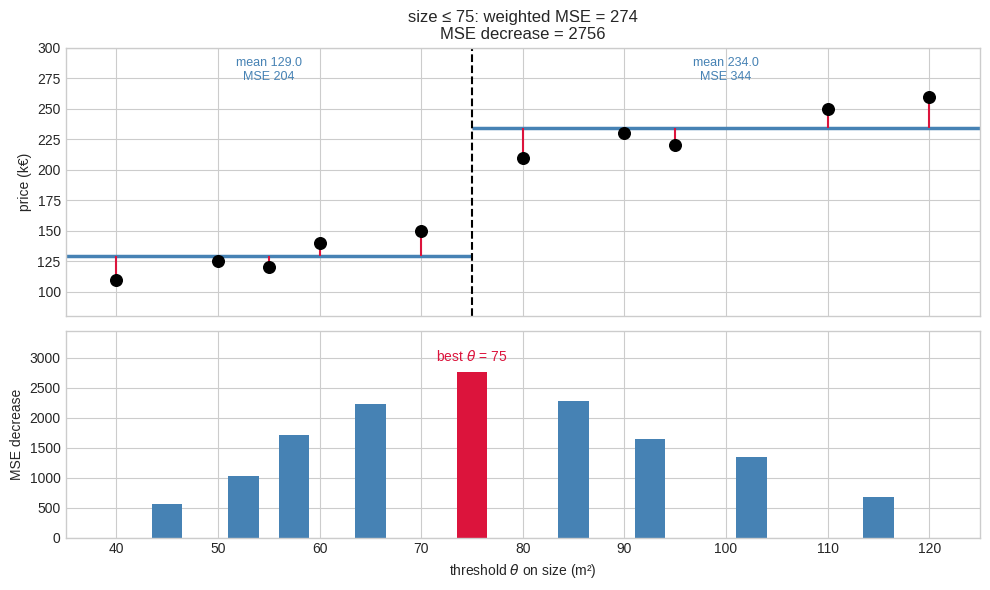

In [24]:
thresholds, gains = threshold_gains(size, price, mse_impurity)
print('  '.join(f"{t:g}->{g:.0f}" for t, g in zip(thresholds, gains)))

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={'height_ratios': [1.3, 1]})
plot_regression_split(ax[0], size, price, threshold=thresholds[np.argmax(gains)])
ax[0].set(xlabel='', ylabel='price (k€)')
plot_gain_scan(ax[1], thresholds, gains, r'threshold $\theta$ on size (m²)', 'MSE decrease')
plt.tight_layout()
plt.show()

The best cut is where the prices jump, between 70 and 80 m². Each side is then summarised by its mean, so a regression tree predicts a **step function** (notes 06, section 8).

**Gini is variance too.** Code *fail* as $0$ and *pass* as $1$. The variance of those 0/1 labels is $p(1-p)$, and the two-class Gini is $1 - p^2 - (1-p)^2 = 2p(1-p)$. So a classification tree with Gini is doing **variance reduction** on 0/1 labels, which is why one algorithm handles both tasks.

In [25]:
print(f"Gini of the students        : {gini(passed):.3f}")
print(f"2 x variance of 0/1 labels  : {2 * np.var(passed):.3f}")

Gini of the students        : 0.500
2 x variance of 0/1 labels  : 0.500


## 7. Recursion: Do It Again on Each Side

After the first split we have two **smaller datasets**, one in each child. Each one is a new problem of exactly the same kind: *"find the best question for these samples"*. So we apply the **same** `best_split` to each child, then to their children, and so on. A function that solves a problem by calling itself on smaller pieces is **recursive**.

```
split_node(samples, depth):
    if stop(samples, depth):                        # pure, too few samples, max depth, no gain
        make a LEAF  (predict majority class / mean)
    else:
        (j, θ) = best_split(samples)
        split_node(samples with x_j ≤ θ, depth + 1)   # left child
        split_node(samples with x_j > θ, depth + 1)   # right child
```

Let's do the second level **by hand** on the students: call `best_split` on each child's samples.

In [26]:
j, thr, gain = best_split(X, y, gini)
left = X[:, j] <= thr
print(f"ROOT : {feature_names[j]} <= {thr:g}  (gain {gain:.3f})")

for side, mask in [('LEFT ', left), ('RIGHT', ~left)]:
    jc, thrc, gainc = best_split(X[mask], y[mask], gini)
    print(f"  {side} child ({counts_text(y[mask])}):  best question = "
          f"{feature_names[jc]} <= {thrc:g}  (gain {gainc:.3f})")

ROOT : studied <= 4.5  (gain 0.180)
  LEFT  child (4 fail · 1 pass):  best question = slept <= 8.5  (gain 0.320)
  RIGHT child (1 fail · 4 pass):  best question = slept <= 4.5  (gain 0.320)


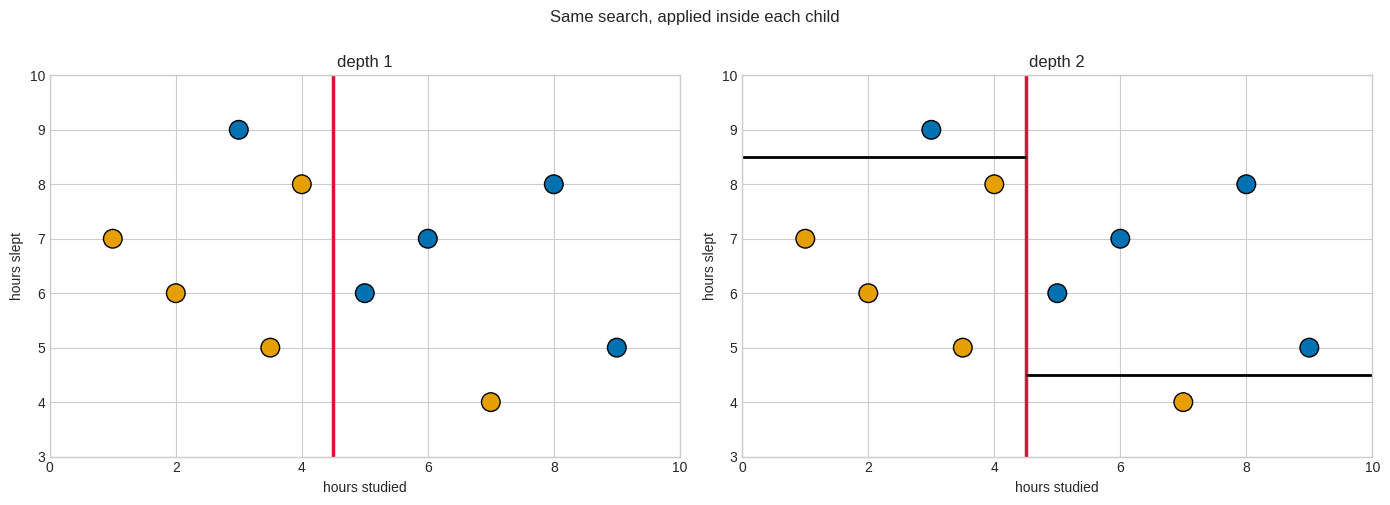

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for a, depth in zip(ax, [1, 2]):
    a.scatter(studied, slept, c=CLASS_COLORS[passed], s=180, edgecolors='k', zorder=3)
    a.axvline(4.5, color='crimson', lw=2.5)
    a.set(xlabel='hours studied', ylabel='hours slept', xlim=(0, 10), ylim=(3, 10))
    if depth == 2:
        a.hlines(8.5, 0, 4.5, color='k', lw=2)      # left child: slept <= 8.5
        a.hlines(4.5, 4.5, 10, color='k', lw=2)     # right child: slept <= 4.5
    a.set_title(f'depth {depth}')
plt.suptitle('Same search, applied inside each child', y=1.0)
plt.tight_layout()
plt.show()

Inside each child, **sleep** becomes the best question, with gain $0.32$: it explains the one exception on each side (the student who studied little but slept 9 h and passed, and the one who studied 7 h but slept 4 h and failed). All four regions are now pure, so recursion stops. At the root sleep looked useless ($0.056$); what matters is how useful a feature is **inside the current node**.

The same thing on a bigger dataset: 4 classes, 300 points (the same blobs you will meet in the next lab). The function below is our recursion, except that instead of storing a tree it **draws** each split line inside its region and colours each leaf by its majority class.

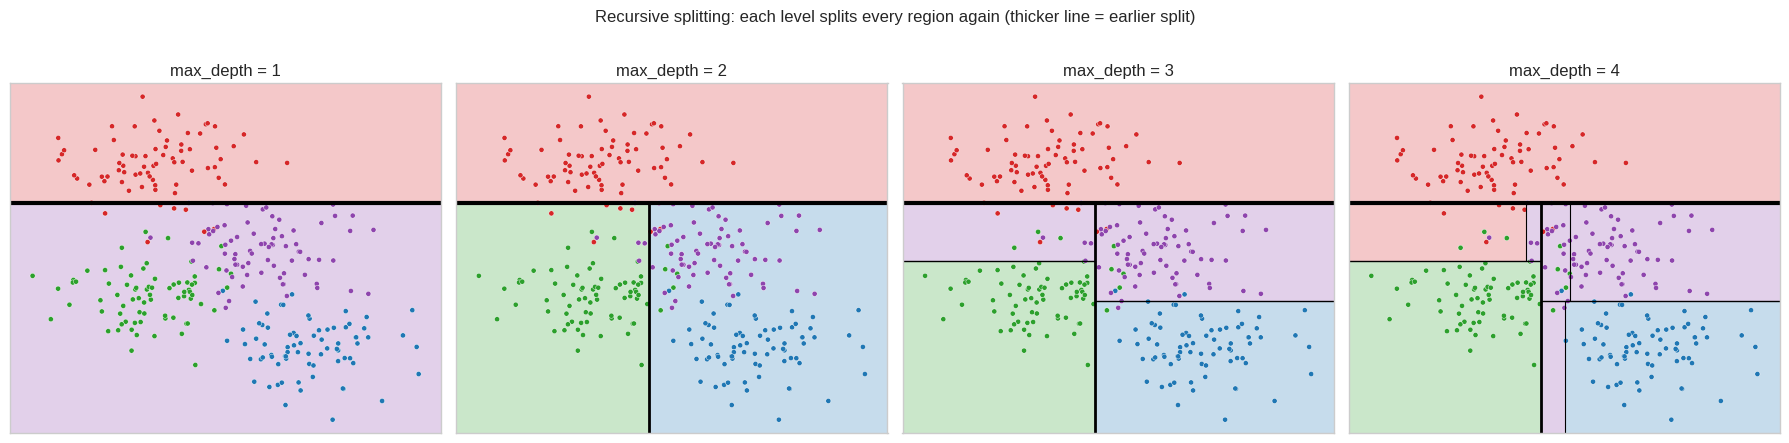

In [28]:
from sklearn.datasets import make_blobs

Xb, yb = make_blobs(n_samples=300, centers=4, random_state=0, cluster_std=1.0)
BLOB_COLORS = np.array(['#8E44AD', '#1F77B4', '#2CA02C', '#D62728'])


def split_and_draw(ax, X, y, bounds, depth, max_depth):
    # bounds = [[x_min, x_max], [y_min, y_max]] of the current region
    feature, thr, gain = best_split(X, y, gini)
    if depth == max_depth or feature is None:            # stop: this region is a leaf
        majority = np.bincount(y).argmax()
        (x0, x1), (y0, y1) = bounds
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, color=BLOB_COLORS[majority], alpha=0.25, lw=0))
        return

    left_bounds = [list(b) for b in bounds]
    right_bounds = [list(b) for b in bounds]
    left_bounds[feature][1] = thr                      # left region: feature <= thr
    right_bounds[feature][0] = thr                     # right region: feature > thr
    if feature == 0:
        ax.plot([thr, thr], bounds[1], 'k-', lw=max(0.8, 3 - depth))
    else:
        ax.plot(bounds[0], [thr, thr], 'k-', lw=max(0.8, 3 - depth))

    left = X[:, feature] <= thr
    split_and_draw(ax, X[left], y[left], left_bounds, depth + 1, max_depth)      # recurse left
    split_and_draw(ax, X[~left], y[~left], right_bounds, depth + 1, max_depth)   # recurse right


bounds = [[Xb[:, 0].min() - 0.5, Xb[:, 0].max() + 0.5], [Xb[:, 1].min() - 0.5, Xb[:, 1].max() + 0.5]]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.3))
for ax, max_depth in zip(axes, [1, 2, 3, 4]):
    split_and_draw(ax, Xb, yb, bounds, depth=0, max_depth=max_depth)
    ax.scatter(Xb[:, 0], Xb[:, 1], c=BLOB_COLORS[yb], s=14, edgecolors='white', linewidths=0.3)
    ax.set(xlim=bounds[0], ylim=bounds[1], xticks=[], yticks=[], title=f'max_depth = {max_depth}')
plt.suptitle('Recursive splitting: each level splits every region again (thicker line = earlier split)', y=1.02)
plt.tight_layout()
plt.show()

- Each level adds lines only **inside** the regions created by the level above, which is why all boundaries are made of axis-aligned rectangles.
- Every call only looks at its own samples and takes the best split **right now**. This is a *greedy* choice: CART never goes back to change an earlier split. Notes 06, section 5 shows a case (XOR) where that is not optimal.
- Deep enough, every region becomes pure, even around single noisy points. That is overfitting; the next lab measures it and fixes it with `max_depth` and random forests.

A full tree adds only bookkeeping on top of this (storing the nodes so it can predict new points). `scikit-learn`'s `DecisionTreeClassifier` and `DecisionTreeRegressor` do exactly that, much faster, and the next lab uses them.

## 8. Exercises

1. **By hand.** A node has 3 pass and 1 fail. Compute its Gini and entropy on paper, then check with `gini` and `entropy`.
2. **A gain by hand.** Compute the Gini gain of *"slept ≤ 8.5?"* on all 10 students (draw the two children first). Check with `split_gain`. Which split from section 1 gives exactly the same gain, and why?
3. **One student changes.** Suppose the student who studied 7 h had passed. Before running anything, predict what happens to the parent impurity and to the right child of *"studied ≤ 4.5?"*. Then change `passed` and re-run the threshold scan.
4. **Why not simply use the error rate?** Another possible impurity is the misclassification rate $1 - \max_k p_k$. A parent has 400 fail and 400 pass. Split A gives children (300 fail, 100 pass) and (100 fail, 300 pass). Split B gives (200 fail, 400 pass) and (200 fail, 0 pass). Compute the gain of A and B with the error rate and with Gini. Which criterion can tell them apart?
5. **Outliers in regression.** Add a flat of 60 m² that costs 400 k€ and re-run the MSE scan of section 6. Does the best threshold move? Why is MSE so sensitive to one point?

<details><summary><b>Solutions</b></summary>

1. $p = (0.75, 0.25)$. Gini $= 1 - (0.5625 + 0.0625) = 0.375$. Entropy $= -(0.75\log_2 0.75 + 0.25\log_2 0.25) = 0.311 + 0.5 = 0.811$ bits.
2. Left (slept ≤ 8.5): 9 students, 5 fail and 4 pass, Gini $0.494$. Right: 1 student (pass), Gini $0$. Weighted $= 0.9 \cdot 0.494 = 0.444$, gain $= 0.5 - 0.444 = 0.056$. Same as *"studied ≤ 1.5?"*: both peel off a single student and leave a 9-student child with the same class counts. The gain only depends on the class counts in the children, not on which feature made them.
3. The parent becomes 6 pass / 4 fail (Gini $0.48$) and the right child becomes pure (Gini $0$). Weighted children $= 0.5 \cdot 0.32 + 0.5 \cdot 0 = 0.16$, so the gain rises from $0.18$ to $0.32$, and $4.5$ is still the best threshold.
4. Error rate: parent $0.5$; A: $0.25$ and $0.25$, weighted $0.25$; B: $1/3$ (weight $0.75$) and $0$, weighted $0.25$. Both gain $0.25$: a tie. Gini: parent $0.5$; A: weighted $0.375$, gain $0.125$; B: $0.75 \cdot 0.444 = 0.333$, gain $0.167$. Gini prefers B, which creates a pure node that needs no further splitting. The error rate only changes when the majority class changes, so it often cannot see progress; Gini and entropy are curved and reward it (notes 06, section 3).
5. See the cell below.
</details>

1) Gini 0.375   entropy 0.811
2) slept <= 8.5 gain 0.056
3) best threshold 4.5, gain 0.320
4) split A: error-rate gain 0.250   Gini gain 0.125
4) split B: error-rate gain 0.250   Gini gain 0.167
5) best threshold with the outlier: 57.5


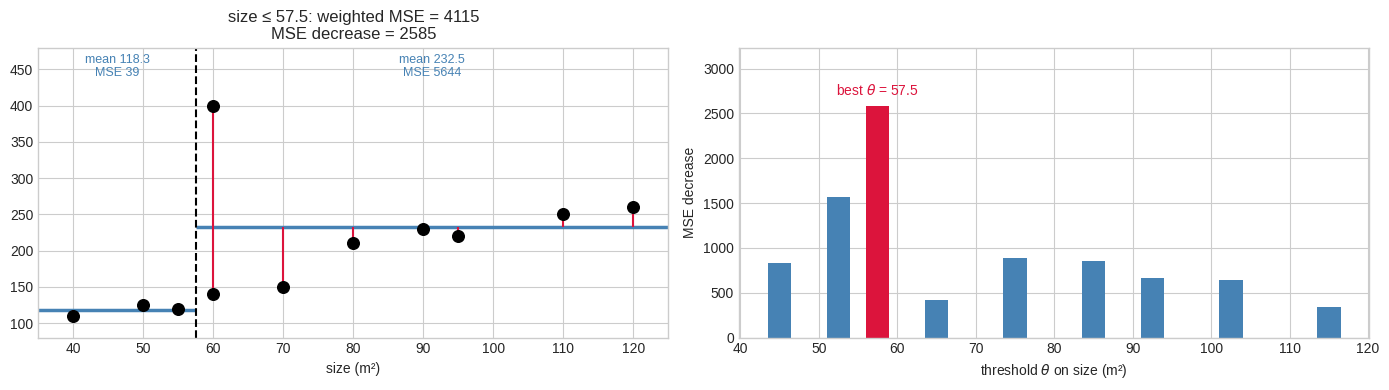

In [29]:
# Solutions 1-4
print(f"1) Gini {gini(np.array([1, 1, 1, 0])):.3f}   entropy {entropy(np.array([1, 1, 1, 0])):.3f}")
print(f"2) slept <= 8.5 gain {split_gain(slept, passed, 8.5, gini):.3f}")

passed_changed = passed.copy()
passed_changed[studied == 7] = 1
t, g = best_threshold(studied, passed_changed, gini)
print(f"3) best threshold {t:g}, gain {g:.3f}")

def misclassification(y):
    _, counts = np.unique(y, return_counts=True)
    return 1 - counts.max() / len(y)

def children_gain(parent, left, right, fn):
    n = len(parent)
    return fn(parent) - (len(left) / n * fn(left) + len(right) / n * fn(right))

labels = lambda n_fail, n_pass: np.array([0] * n_fail + [1] * n_pass)
parent = labels(400, 400)
for name, (l, r) in {'A': (labels(300, 100), labels(100, 300)), 'B': (labels(200, 400), labels(200, 0))}.items():
    print(f"4) split {name}: error-rate gain {children_gain(parent, l, r, misclassification):.3f}   "
          f"Gini gain {children_gain(parent, l, r, gini):.3f}")

# Solution 5
size_o, price_o = np.append(size, 60), np.append(price, 400)
thresholds, gains = threshold_gains(size_o, price_o, mse_impurity)
print(f"5) best threshold with the outlier: {thresholds[np.argmax(gains)]:g}")
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_regression_split(ax[0], size_o, price_o, threshold=thresholds[np.argmax(gains)], ylim=(80, 480))
plot_gain_scan(ax[1], thresholds, gains, r'threshold $\theta$ on size (m²)', 'MSE decrease')
plt.tight_layout()
plt.show()

The best cut moves from $75$ to $57.5$ m²: the natural price jump at 70-80 m² is no longer chosen, because the squared error of one extreme flat dominates the MSE. Squaring makes large errors count a lot, which is why regression trees (like least squares) are sensitive to outliers.

## Summary

- A **split** is one question $x_j \le \theta$: yes goes left, no goes right.
- **Impurity** measures how mixed a node is: **Gini** $1-\sum p_k^2$ or **entropy** $-\sum p_k \log_2 p_k$ for classes, **MSE** (variance) for numbers. All are $0$ for a pure node.
- The **gain** of a split is parent impurity minus the **size-weighted** impurity of the children (information gain, Gini decrease, MSE decrease).
- To find the best split: try the **midpoint** between every pair of neighbouring values, on **every** feature, and keep the largest gain.
- A tree applies that same search **recursively** to each child until a stopping rule holds. Next lab: full trees in `scikit-learn`, overfitting, and random forests.